# Part 2. Simulation and tests
Compare the Black basket with its three-moment shifted-lognormal approximation.
Run all cells in order. Inputs are synthetic; only NumPy, SciPy, pandas and Matplotlib are needed.

Signed weights are allowed. Positive/negative third moments give positive/reflected shifted lognormals; zero third moment with positive variance gives a normal approximation. Zero variance gives a constant.
In the normal branch, $\widehat B_T=\mathbb E[B_T]+\sqrt{\operatorname{Var}(B_T)}Z$; $\widehat C,\widehat F,\widehat\sigma$ have no finite fitted values.

## 1. Inputs and analytical moments
Keep the same inputs, simulation counts and seeds so the results remain comparable.
The loops below implement Part 1. `expm1(x)` means $e^x-1$; `fsum` reduces rounding error when signed terms cancel.

In [1]:
from math import fsum
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

pd.set_option("display.float_format", lambda value: f"{value:,.6g}")
pd.set_option("display.max_columns", 14)
SEED, N_MAIN, N_SCENARIO, N_REPEATS = 20260910, 150_000, 60_000, 12
ALPHA = 0.05
f0 = np.array([100.0, 95.0, 105.0])
weights = np.array([0.40, 0.35, 0.25])
vol = np.array([0.20, 0.30, 0.40])
corr = np.array([[1.00, 0.50, 0.25],
                 [0.50, 1.00, 0.40],
                 [0.25, 0.40, 1.00]])
T = 1.0
discount_factor = 1.0  # Replace by D(0,T) to turn expected payoffs into prices.

In [2]:
def basket_moments(f0, weights, vol, corr, T):
    f0, weights = np.asarray(f0, float), np.asarray(weights, float)
    vol, corr = np.asarray(vol, float), np.asarray(corr, float)
    n = len(f0)
    assert n > 0 and weights.shape == vol.shape == (n,) and corr.shape == (n, n)
    assert T > 0 and np.isfinite(T) and np.all(f0 > 0) and np.all(vol >= 0)
    assert all(np.isfinite(values).all() for values in [f0, weights, vol, corr])
    assert np.allclose(corr, corr.T, atol=1e-12, rtol=0)
    assert np.allclose(np.diag(corr), 1, atol=1e-12, rtol=0)
    assert np.linalg.eigvalsh(corr).min() >= -1e-12, "Invalid correlation matrix"
    initial_holdings = weights * f0
    exp_minus_one = np.expm1(T * np.outer(vol, vol) * corr)
    variance_terms, third_terms = [], []
    for i in range(n):
        for j in range(n):
            variance_terms.append(initial_holdings[i] * initial_holdings[j] * exp_minus_one[i, j])
            for k in range(n):
                # Expand exp(a+b+c)-exp(a)-exp(b)-exp(c)+2 without subtracting large numbers.
                cross_ij, cross_ik, cross_jk = exp_minus_one[i, j], exp_minus_one[i, k], exp_minus_one[j, k]
                third_terms.append(initial_holdings[i] * initial_holdings[j] * initial_holdings[k] *
                    (cross_ij*cross_ik + cross_ij*cross_jk + cross_ik*cross_jk + cross_ij*cross_ik*cross_jk))
    mean = fsum(initial_holdings)
    variance, central3 = fsum(variance_terms), fsum(third_terms)
    assert variance >= 0 and np.isfinite([mean, variance, central3]).all()
    return {"mean": mean, "variance": variance, "central3": central3,
            "m2": variance + mean**2, "m3": central3 + 3*mean*variance + mean**3,
            "skewness": central3 / variance**1.5 if variance > 0 else np.nan}


def fit_three_moments(moments, T):
    mean, variance, central3 = moments["mean"], moments["variance"], moments["central3"]
    if variance == 0:
        assert central3 == 0
        return mean, 0.0, 0.0  # C_hat, F_hat, sigma_hat: a constant basket.
    if central3 == 0:
        return None, None, None  # Normal branch: these three parameters do not exist.
    F_hat = np.sqrt(variance) / (2*np.sinh(np.arcsinh(central3 / (2*variance**1.5)) / 3))
    C_hat = mean - F_hat
    sigma_hat = np.sqrt(np.log1p(variance / F_hat**2) / T)
    return C_hat, F_hat, sigma_hat


moments = basket_moments(f0, weights, vol, corr, T)
C_hat, F_hat, sigma_hat = fit_three_moments(moments, T)
basket_mean, basket_sd = moments["mean"], np.sqrt(moments["variance"])
display(pd.Series(moments, name="Basket moments").to_frame())
if F_hat is None:
    print(f"Normal fit: mean={basket_mean:g}, standard deviation={basket_sd:g}; no shifted-lognormal parameters.")
else:
    display(pd.Series({"C_hat": C_hat, "F_hat": F_hat, "sigma_hat": sigma_hat}, name="Fit").to_frame())

,Basket moments
mean,99.5
variance,498.238
central3,"8,449.43"
m2,"10,398.5"
m3,1.14225e+06
skewness,0.759752


,Fit
C_hat,9.55183
F_hat,89.9482
sigma_hat,0.244459


## 2. Simulate and check known answers
Draw correlated normals, then apply the exact terminal Black formula. The eigenvalue square root also handles perfect correlation.
SciPy's `lognorm` uses shape $\widehat\sigma\sqrt T$, location $\widehat C$, and scale $\widehat F e^{-\widehat\sigma^2T/2}$ ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.lognorm.html)).
For negative $\widehat F$, model $-\widehat B_T$ with SciPy and reflect it: the CDF uses the survival function and quantiles reverse their probabilities. `None` means the normal branch, never a numerical value for $\widehat F$.

In [3]:
def simulate_basket(f0, weights, vol, corr, T, n_draws, rng):
    f0, vol = np.asarray(f0), np.asarray(vol)
    eigenvalues, eigenvectors = np.linalg.eigh(corr)
    assert eigenvalues.min() >= -1e-12, "Invalid correlation matrix"
    correlation_root = eigenvectors @ np.diag(np.sqrt(np.maximum(eigenvalues, 0)))
    normals = rng.standard_normal((n_draws, len(f0))) @ correlation_root.T
    forwards = f0 * np.exp(-0.5*vol**2*T + vol*np.sqrt(T)*normals)
    return forwards @ weights


def fitted_distribution(moments, T):
    C_hat, F_hat, sigma_hat = fit_three_moments(moments, T)
    if F_hat is None:
        return stats.norm(moments["mean"], np.sqrt(moments["variance"])), 1
    if F_hat == 0:
        raise ValueError("A constant basket needs no continuous-distribution comparison.")
    direction = 1 if F_hat > 0 else -1
    distribution = stats.lognorm(sigma_hat*np.sqrt(T), loc=direction*C_hat,
                                scale=abs(F_hat)*np.exp(-0.5*sigma_hat**2*T))
    return distribution, direction  # Model variable = direction * SciPy variable.


def fitted_cdf(x, distribution, direction=1):
    return distribution.cdf(x) if direction == 1 else distribution.sf(-x)


def fitted_quantile(p, distribution, direction=1):
    return distribution.ppf(p) if direction == 1 else -distribution.ppf(1-np.asarray(p))


basket_seed, fit_seed = np.random.SeedSequence(SEED).spawn(2)
basket_sample = simulate_basket(f0, weights, vol, corr, T, N_MAIN, np.random.default_rng(basket_seed))
Z = np.random.default_rng(fit_seed).standard_normal(N_MAIN)
# Equivalent to C_hat + F_hat*exp(...), but avoids subtracting a large shift from a large scale.
if F_hat is None:
    fit_sample = basket_mean + basket_sd*Z
else:
    fit_sample = basket_mean + F_hat*np.expm1(-0.5*sigma_hat**2*T + sigma_hat*np.sqrt(T)*Z)
fit_dist, fit_direction = fitted_distribution(moments, T)
# Ordinary two-moment lognormal benchmark: zero shift, matched mean and variance.
dist_2mm, benchmark_moments = None, None
if basket_mean > 0:
    sigma_2mm = np.sqrt(np.log1p(basket_sd**2 / basket_mean**2) / T)
    dist_2mm = stats.lognorm(sigma_2mm*np.sqrt(T), scale=basket_mean*np.exp(-0.5*sigma_2mm**2*T))
    benchmark_moments = {"mean": basket_mean, "variance": basket_sd**2,
                         "central3": 3*basket_sd**4/basket_mean + basket_sd**6/basket_mean**3}

In [4]:
# Known answers: one forward, a common factor, a shifted forward, and a constant.
known_cases = [
    ([100], [1], [0.30], [[1]], 2.0, [0, 100, 0.30]),
    (f0, weights, [0.25]*3, np.ones((3, 3)), T, [0, weights @ f0, 0.25]),
    ([30, 70], [1, 1], [0, 0.25], np.eye(2), T, [30, 70, 0.25]),
    (f0, weights, np.zeros(3), corr, T, [weights @ f0, 0, 0]),
    ([100], [-1], [0.30], [[1]], T, [0, -100, 0.30]),
]
for forwards, holdings, vols, correlations, maturity, expected in known_cases:
    actual = fit_three_moments(basket_moments(forwards, holdings, vols, correlations, maturity), maturity)
    np.testing.assert_allclose(actual, expected, atol=1e-10)
np.testing.assert_allclose(simulate_basket(f0, weights, np.zeros(3), corr, T, 20, np.random.default_rng(1)), basket_mean)
# Equal independent forwards with opposite weights have zero skew and positive variance.
zero_skew = basket_moments([100, 100], [1, -1], [0.3, 0.3], np.eye(2), T)
assert zero_skew["variance"] > 0 and zero_skew["central3"] == 0
assert fit_three_moments(zero_skew, T) == (None, None, None)
try:
    basket_moments([100, 100], [1, 1], [0.3, 0.3], [[1, 1.2], [1.2, 1]], T)
except AssertionError:
    pass
else:
    raise AssertionError("Invalid correlation was accepted")
print("Known-answer and invalid-input checks passed.")

Known-answer and invalid-input checks passed.


## 3. Moments and distribution plots
The first three analytical moments should match. Simulation errors are shown in Monte Carlo standard errors (SE).
The fourth moment is a separate check because it was not used to fit the distribution; kurtosis means the fourth central moment divided by variance squared.

In [5]:
raw_basket = np.array([basket_mean, moments["m2"], moments["m3"]])
if F_hat is None:
    raw_fit = np.array([basket_mean, basket_mean**2+basket_sd**2, basket_mean**3+3*basket_mean*basket_sd**2])
else:
    raw_fit = np.array([C_hat + F_hat,
        C_hat**2 + 2*C_hat*F_hat + F_hat**2*np.exp(sigma_hat**2*T),
        C_hat**3 + 3*C_hat**2*F_hat + 3*C_hat*F_hat**2*np.exp(sigma_hat**2*T) + F_hat**3*np.exp(3*sigma_hat**2*T)])
np.testing.assert_allclose(raw_fit, raw_basket, rtol=2e-12, atol=1e-9)
display(pd.DataFrame({"basket": raw_basket, "fit": raw_fit,
    "difference": raw_fit-raw_basket}, index=[1, 2, 3]))
moment_rows = []
for label, sample in [("basket", basket_sample), ("fit", fit_sample)]:
    for order, target in enumerate(raw_basket, 1):
        powers = sample**order
        estimate, se = powers.mean(), powers.std(ddof=1)/np.sqrt(len(sample))
        moment_rows.append({"sample": label, "order": order, "analytical": target,
            "MC_estimate": estimate, "MC_SE": se, "difference_in_SE": (estimate-target)/se})
display(pd.DataFrame(moment_rows))

,basket,fit,difference
1,99.5,99.5,0
2,"10,398.5","10,398.5",-1.81899e-12
3,1.14225e+06,1.14225e+06,-2.32831e-10


,sample,order,analytical,MC_estimate,MC_SE,difference_in_SE
0,basket,1,99.5,99.4459,0.0575892,-0.940268
1,basket,2,"10,398.5","10,387",12.5967,-0.915901
2,basket,3,1.14225e+06,1.14032e+06,"2,238.03",-0.862378
3,fit,1,99.5,99.5092,0.0576575,0.159374
4,fit,2,"10,398.5","10,400.7",12.617,0.178037
5,fit,3,1.14225e+06,1.1427e+06,"2,236.54",0.2008


In [6]:
def basket_fourth_moment(f0, weights, vol, corr, T):
    initial_holdings = np.asarray(f0)*weights
    log_covariance = T*np.outer(vol, vol)*corr
    fourth = 0.0
    # Four indices, with all six covariance pairs in each exponential.
    for i, j, k, l in product(range(len(f0)), repeat=4):
        exponent = (log_covariance[i,j] + log_covariance[i,k] + log_covariance[i,l]
                    + log_covariance[j,k] + log_covariance[j,l] + log_covariance[k,l])
        fourth += initial_holdings[i]*initial_holdings[j]*initial_holdings[k]*initial_holdings[l]*np.exp(exponent)
    return fourth


m4 = basket_fourth_moment(f0, weights, vol, corr, T)
if F_hat is None:
    m4_fit = basket_mean**4 + 6*basket_mean**2*basket_sd**2 + 3*basket_sd**4
    kurtosis_fit = 3.0
else:
    m4_fit = (C_hat**4 + 4*C_hat**3*F_hat + 6*C_hat**2*F_hat**2*np.exp(sigma_hat**2*T)
              + 4*C_hat*F_hat**3*np.exp(3*sigma_hat**2*T) + F_hat**4*np.exp(6*sigma_hat**2*T))
    kurtosis_fit = np.exp(4*sigma_hat**2*T) + 2*np.exp(3*sigma_hat**2*T) + 3*np.exp(2*sigma_hat**2*T) - 3
kurtosis_basket = (m4 - 4*basket_mean*moments["m3"] + 6*basket_mean**2*moments["m2"] - 3*basket_mean**4)/basket_sd**4
display(pd.DataFrame({"basket": [m4, kurtosis_basket], "fit": [m4_fit, kurtosis_fit]}, index=["fourth moment", "kurtosis"]))

,basket,fit
fourth moment,1.31991e+08,1.31978e+08
kurtosis,4.09679,4.04361


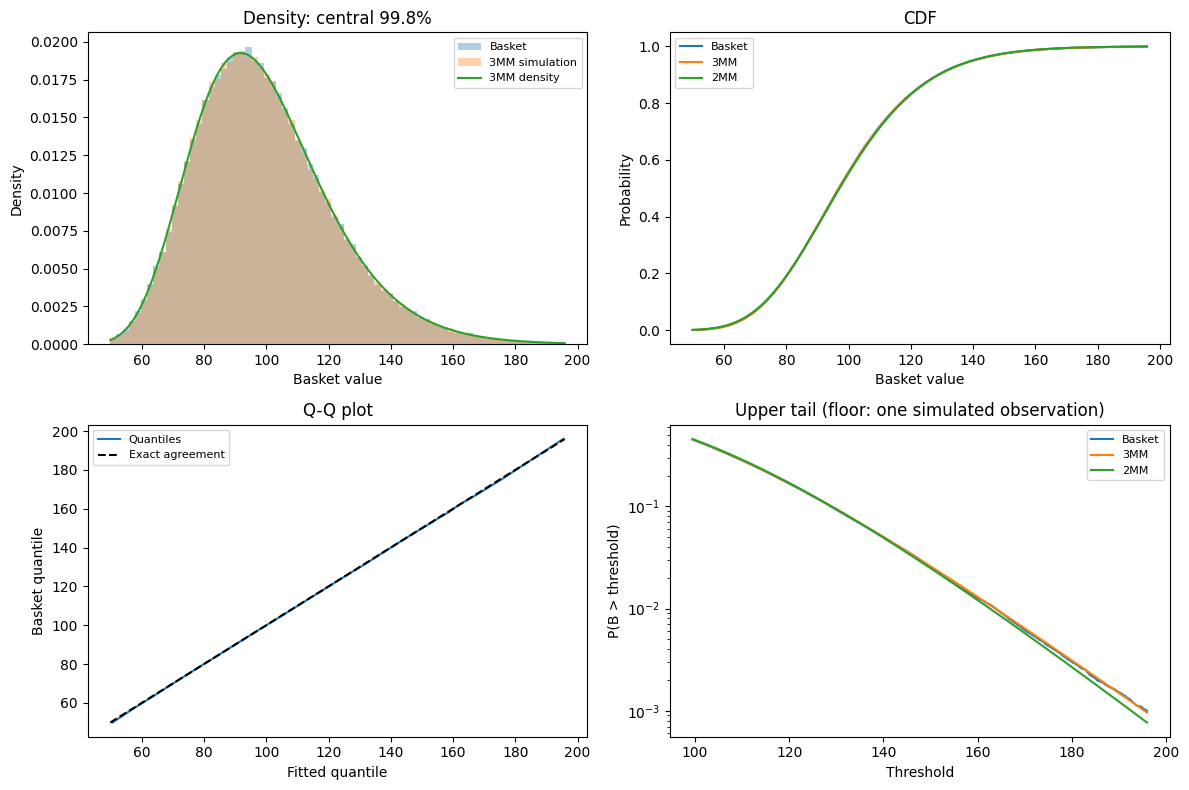

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
lo = min(np.quantile(basket_sample, 0.001), fitted_quantile(0.001, fit_dist, fit_direction))
hi = max(np.quantile(basket_sample, 0.999), fitted_quantile(0.999, fit_dist, fit_direction))
bins, grid = np.linspace(lo, hi, 75), np.linspace(lo, hi, 700)
# Use full-sample weights so cropping the histogram does not inflate its density.
for sample, label in [(basket_sample, "Basket"), (fit_sample, "3MM simulation")]:
    axes[0,0].hist(sample, bins=bins, weights=np.full(N_MAIN, 1/(N_MAIN*(bins[1]-bins[0]))), alpha=0.35, label=label)
axes[0,0].plot(grid, fit_dist.pdf(fit_direction*grid), label="3MM density")
axes[0,0].set(title="Density: central 99.8%", xlabel="Basket value", ylabel="Density")
ordered = np.sort(basket_sample)
axes[0,1].plot(grid, np.searchsorted(ordered, grid, side="right")/N_MAIN, label="Basket")
for distribution, direction, label in [(fit_dist, fit_direction, "3MM"), (dist_2mm, 1, "2MM")]:
    if distribution is not None:
        axes[0,1].plot(grid, fitted_cdf(grid, distribution, direction), label=label)
axes[0,1].set(title="CDF", xlabel="Basket value", ylabel="Probability")
probabilities = np.linspace(0.001, 0.999, 300)
axes[1,0].plot(fitted_quantile(probabilities, fit_dist, fit_direction), np.quantile(basket_sample, probabilities), label="Quantiles")
axes[1,0].plot([lo, hi], [lo, hi], "k--", label="Exact agreement")
axes[1,0].set(title="Q-Q plot", xlabel="Fitted quantile", ylabel="Basket quantile")
tail_grid = np.linspace(basket_mean, hi, 400)
tail_frequency = 1 - np.searchsorted(ordered, tail_grid, side="right")/N_MAIN
axes[1,1].semilogy(tail_grid, np.maximum(tail_frequency, 1/N_MAIN), label="Basket")
for distribution, direction, label in [(fit_dist, fit_direction, "3MM"), (dist_2mm, 1, "2MM")]:
    if distribution is not None:
        survival = distribution.sf(tail_grid) if direction == 1 else distribution.cdf(-tail_grid)
        axes[1,1].semilogy(tail_grid, survival, label=label)
axes[1,1].set(title="Upper tail (floor: one simulated observation)", xlabel="Threshold", ylabel="P(B > threshold)")
for ax in axes.flat:
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 4. CDF, quantiles and tails
The maximum CDF gap is measured on both sides of every empirical jump. Its 95% DKW margin is $\sqrt{\log(40)/(2N)}$, where $N$ is the simulation count ([bound](https://arxiv.org/abs/1107.5356)).
The KS p-value is valid because the fit uses analytical inputs, not this simulation sample. Judge the gap's size as well as its p-value ([KS assumptions](https://www.itl.nist.gov/div898/handbook/eda/section3/eda35g.htm)).

In [8]:
def cdf_diagnostics(sample, distribution, alpha=ALPHA, direction=1):
    ordered = np.sort(sample)
    n = len(ordered)
    probabilities = fitted_cdf(ordered, distribution, direction)
    distance = max(np.max(np.arange(1, n+1)/n - probabilities), np.max(probabilities - np.arange(n)/n))
    margin = np.sqrt(np.log(2/alpha)/(2*n))
    return distance, max(0, distance-margin), min(1, distance+margin)


cdf_rows = []
for label, distribution, direction in [("3MM", fit_dist, fit_direction), ("2MM lognormal", dist_2mm, 1)]:
    if distribution is None:
        continue
    distance, lower, upper = cdf_diagnostics(basket_sample, distribution, direction=direction)
    pvalue = stats.kstest(basket_sample, lambda x: fitted_cdf(x, distribution, direction), method="asymp").pvalue
    cdf_rows.append({"model": label, "D_empirical": distance,
                    "D_lower": lower, "D_upper": upper, "KS_pvalue": pvalue})
cdf_table = pd.DataFrame(cdf_rows).set_index("model")
display(cdf_table)

,D_empirical,D_lower,D_upper,KS_pvalue
model,,,,
3MM,0.00200123,0,0.00550783,0.585178
2MM lognormal,0.00613014,0.00262354,0.00963675,2.5408e-05


Quantile bounds invert the same simultaneous DKW band; extreme-tail bounds may be infinite.
Four fixed tail thresholds use exact binomial intervals with a Bonferroni adjustment for 95% joint coverage ([interval method](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats._result_classes.BinomTestResult.proportion_ci.html)). A zero event count does not prove zero probability.

In [9]:
margin = np.sqrt(np.log(2/ALPHA)/(2*N_MAIN))
quantile_rows = []
for p in [0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999]:
    # 'inverted_cdf' uses observed order statistics, with no interpolation.
    empirical_q = np.quantile(basket_sample, p, method="inverted_cdf")
    lower = np.quantile(basket_sample, p-margin, method="inverted_cdf") if p > margin else -np.inf
    upper = np.quantile(basket_sample, p+margin, method="inverted_cdf") if p+margin < 1 else np.inf
    fitted_q = fitted_quantile(p, fit_dist, fit_direction)
    quantile_rows.append({"p": p, "basket_MC_quantile": empirical_q, "fit_quantile": fitted_q,
        "error_in_basket_SD": (fitted_q-empirical_q)/basket_sd, "basket_q_lower": lower, "basket_q_upper": upper,
        "fit_minus_true_lower": fitted_q-upper, "fit_minus_true_upper": fitted_q-lower})
quantile_table = pd.DataFrame(quantile_rows)
display(quantile_table)
tail_rows = []
for p in [0.01, 0.05, 0.95, 0.99]:
    threshold = fitted_quantile(p, fit_dist, fit_direction)
    event = basket_sample <= threshold if p < 0.5 else basket_sample > threshold
    probability = p if p < 0.5 else 1-p
    interval = stats.binomtest(int(event.sum()), N_MAIN).proportion_ci(1-ALPHA/4, method="exact")
    tail_rows.append({"event": f"B {'<=' if p < 0.5 else '>'} fitted Q({p})", "threshold": threshold,
        "events": int(event.sum()), "basket_probability": event.mean(), "fit_probability": probability,
        "joint_CI_lower": interval.low, "joint_CI_upper": interval.high,
        "fit_outside_CI": not interval.low <= probability <= interval.high})
tail_table = pd.DataFrame(tail_rows)
display(tail_table)
if F_hat is not None:
    excluded = basket_sample <= C_hat if F_hat > 0 else basket_sample >= C_hat
    support_ci = stats.binomtest(int(excluded.sum()), N_MAIN).proportion_ci(1-ALPHA, method="exact")
    print(f"Basket observations outside fitted support: {excluded.sum()}; probability CI: [{support_ci.low:.6g}, {support_ci.high:.6g}]")
else:
    print("The normal fit has no finite support endpoint.")
if np.all(weights >= 0):
    print(f"Fit probability below zero: {fitted_cdf(0, fit_dist, fit_direction):.6g}; true basket probability: 0.")

,p,basket_MC_quantile,fit_quantile,error_in_basket_SD,basket_q_lower,basket_q_upper,fit_minus_true_lower,fit_minus_true_upper
0,0.001,49.852,50.5661,0.0319892,-inf,55.3453,-4.77926,inf
1,0.01,58.7114,58.9868,0.0123367,56.8095,60.14,-1.15324,2.17731
2,0.05,67.844,67.9483,0.00467058,67.3243,68.3296,-0.38135,0.623984
3,0.5,96.848,96.8521,0.000185728,96.6431,97.0191,-0.167013,0.208996
4,0.95,140.014,140.062,0.00214365,138.973,141.128,-1.06627,1.08897
5,0.99,163.789,163.721,-0.00304534,158.981,169.316,-5.59546,4.7398
6,0.999,195.901,195.374,-0.0236366,174.408,inf,-inf,20.9651


,event,threshold,events,basket_probability,fit_probability,joint_CI_lower,joint_CI_upper,fit_outside_CI
0,B <= fitted Q(0.01),58.9868,1595,0.0106333,0.01,0.00998321,0.011313,False
1,B <= fitted Q(0.05),67.9483,7608,0.05072,0.05,0.0493151,0.0521519,False
2,B > fitted Q(0.95),140.062,7474,0.0498267,0.05,0.0484336,0.0512468,False
3,B > fitted Q(0.99),163.721,1507,0.0100467,0.01,0.00941487,0.010708,False


Basket observations outside fitted support: 0; probability CI: [0, 2.45922e-05]
Fit probability below zero: 0; true basket probability: 0.


## 5. Calls and puts
Compare analytical fitted payoffs with basket Monte Carlo estimates at six strikes. The code writes out the Black formula; returns are **call, put**.
For a reflected fit, a call on the basket is a put on its negative, with the strike negated. For zero skewness, the code uses the normal expected-payoff formula.
Error intervals are pointwise 95% normal approximations. Relative errors are omitted when the estimated payoff is too small compared with its SE.

,kind,strike,basket_MC,MC_SE,fit_3MM,fit_2MM,error_3MM,error_lower,error_upper,relative_error
0,call,54.8575,44.6025,0.0575104,44.6541,44.6605,0.0515482,-0.0611723,0.164269,0.00115572
1,put,54.8575,0.014191,0.000788681,0.01159,0.0180091,-0.00260108,-0.00414689,-0.00105526,-0.18329
2,call,77.1788,23.4207,0.0535515,23.4602,23.5309,0.03949,-0.065471,0.144451,0.00168611
3,put,77.1788,1.15359,0.00940785,1.13893,1.20968,-0.0146593,-0.0330987,0.00378011,-0.0127075
4,call,99.5,8.70556,0.038285,8.75039,8.77784,0.0448363,-0.0302023,0.119875,0.00515031
5,put,99.5,8.7597,0.0288789,8.75039,8.77784,-0.00931296,-0.0659156,0.0472897,-0.00106316
6,call,121.821,2.40628,0.0210962,2.42556,2.38148,0.019275,-0.0220735,0.0606236,0.0080103
7,put,121.821,24.7817,0.0455672,24.7468,24.7027,-0.0348742,-0.124186,0.0544375,-0.00140726
8,call,144.142,0.550748,0.0101315,0.553914,0.516172,0.00316551,-0.0166922,0.0230232,0.00574764
9,put,144.142,45.2474,0.0536805,45.1964,45.1587,-0.0509837,-0.156198,0.0542301,-0.00112678


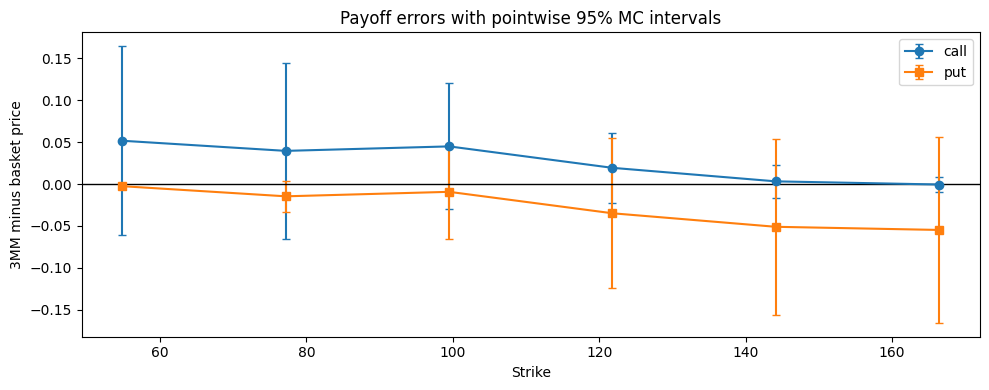

In [10]:
def fitted_payoff(moments, T, strike):
    C_hat, F_hat, sigma_hat = fit_three_moments(moments, T)
    if F_hat is None:
        mean, sd = moments["mean"], np.sqrt(moments["variance"])
        z = (mean-strike)/sd
        call = (mean-strike)*stats.norm.cdf(z) + sd*stats.norm.pdf(z)
        put = (strike-mean)*stats.norm.cdf(-z) + sd*stats.norm.pdf(z)
        return call, put
    if F_hat == 0:
        return max(C_hat-strike, 0), max(strike-C_hat, 0)
    reflected = F_hat < 0
    if reflected:
        C_hat, F_hat, strike = -C_hat, -F_hat, -strike
    if strike <= C_hat:
        call, put = C_hat+F_hat-strike, 0.0
    else:
        adjusted_strike = strike-C_hat
        d2 = (np.log(F_hat/adjusted_strike) - 0.5*sigma_hat**2*T)/(sigma_hat*np.sqrt(T))
        d1 = d2 + sigma_hat*np.sqrt(T)
        call = F_hat*stats.norm.cdf(d1) - adjusted_strike*stats.norm.cdf(d2)
        put = adjusted_strike*stats.norm.cdf(-d2) - F_hat*stats.norm.cdf(-d1)
    return (put, call) if reflected else (call, put)  # Reflection exchanges calls and puts.


payoff_rows = []
for offset in [-2, -1, 0, 1, 2, 3]:
    strike = basket_mean + offset*basket_sd
    fitted_prices = fitted_payoff(moments, T, strike)
    benchmark_prices = fitted_payoff(benchmark_moments, T, strike) if benchmark_moments else [np.nan, np.nan]
    for position, (kind, sign) in enumerate([("call", 1), ("put", -1)]):
        payoff = discount_factor*np.maximum(sign*(basket_sample-strike), 0)
        mc_price, se = payoff.mean(), payoff.std(ddof=1)/np.sqrt(N_MAIN)
        price = discount_factor*fitted_prices[position]
        error = price-mc_price
        payoff_rows.append({"kind": kind, "strike": strike, "basket_MC": mc_price, "MC_SE": se,
            "fit_3MM": price, "fit_2MM": discount_factor*benchmark_prices[position], "error_3MM": error,
            "error_lower": error-1.96*se, "error_upper": error+1.96*se,
            "relative_error": error/mc_price if mc_price > 10*se and mc_price > 0 else np.nan})
payoff_table = pd.DataFrame(payoff_rows)
display(payoff_table)
for strike in [basket_mean-3*basket_sd, basket_mean, basket_mean+3*basket_sd]:
    call, put = fitted_payoff(moments, T, strike)
    np.testing.assert_allclose(call-put, basket_mean-strike, atol=1e-10)
fig, ax = plt.subplots(figsize=(10, 4))
for kind, marker in [("call", "o"), ("put", "s")]:
    rows = payoff_table[payoff_table["kind"] == kind]
    ax.errorbar(rows["strike"], rows["error_3MM"], yerr=1.96*rows["MC_SE"], fmt=marker+"-", capsize=3, label=kind)
ax.axhline(0, color="black", linewidth=1)
ax.set(xlabel="Strike", ylabel="3MM minus basket price", title="Payoff errors with pointwise 95% MC intervals")
ax.legend()
fig.tight_layout()
plt.show()

## 6. Stress tests and repeated samples
The same 11 scenarios change the named input. Each uses fresh draws; CDF bounds are adjusted for 95% joint coverage across all scenarios.
Three additional cases check negative and zero skewness in a separate table, with their own joint intervals.
Quantile errors, kurtosis errors and support failures reveal discrepancies not fixed by matching three moments. Payoff errors and quantile errors are divided by basket SD for comparison.

In [11]:
scenarios = [
    ("Base", f0, weights, vol, corr, T),
    ("One forward: exact", [100], [1], [0.30], [[1]], T),
    ("Perfect common factor: exact", f0, weights, [0.25]*3, np.ones((3, 3)), T),
    ("Independent drivers", f0, weights, vol, np.eye(3), T),
    ("Negative correlation", f0, weights, vol, 1.4*np.eye(3)-0.4*np.ones((3, 3)), T),
    ("High correlation", f0, weights, vol, 0.1*np.eye(3)+0.9*np.ones((3, 3)), T),
    ("Heterogeneous volatilities", f0, weights, [0.10, 0.30, 0.80], corr, T),
    ("Long maturity: 5 years", f0, weights, vol, corr, 5.0),
    ("Short maturity: 0.05 years", f0, weights, vol, corr, 0.05),
    ("Concentrated weights", f0, [0.90, 0.07, 0.03], vol, corr, T),
    ("Signed spread", [100, 100], [1, -0.8], [0.40, 0.20], [[1, 0.3], [0.3, 1]], T),
]
signed_scenarios = [
    ("Negative: single short (exact)", [100], [-1], [0.30], [[1]], T),
    ("Negative: signed spread", [100, 100], [1, -0.8], [0.20, 0.40], [[1, 0.3], [0.3, 1]], T),
    ("Zero: symmetric spread", [100, 100], [1, -1], [0.30, 0.30], np.eye(2), T),
]
scenario_rows = []
scenario_seeds = np.random.SeedSequence(SEED+1).spawn(len(scenarios))
scenario_seeds += np.random.SeedSequence(SEED+3).spawn(len(signed_scenarios))
for index, (inputs, seed) in enumerate(zip(scenarios+signed_scenarios, scenario_seeds)):
    name, forwards, holdings, vols, correlations, maturity = inputs
    scenario_moments = basket_moments(forwards, holdings, vols, correlations, maturity)
    shift, scale, fitted_vol = fit_three_moments(scenario_moments, maturity)
    distribution, direction = fitted_distribution(scenario_moments, maturity)
    sample = simulate_basket(forwards, holdings, vols, correlations, maturity, N_SCENARIO, np.random.default_rng(seed))
    group_size = len(scenarios) if index < len(scenarios) else len(signed_scenarios)
    distance, lower, upper = cdf_diagnostics(sample, distribution, ALPHA/group_size, direction)
    mean, variance = scenario_moments["mean"], scenario_moments["variance"]
    sd = np.sqrt(variance)
    sample_call = np.maximum(sample-mean, 0)
    call_error = fitted_payoff(scenario_moments, maturity, mean)[0] - sample_call.mean()
    fourth = basket_fourth_moment(forwards, holdings, vols, correlations, maturity)
    true_kurtosis = (fourth - 4*mean*scenario_moments["m3"] + 6*mean**2*scenario_moments["m2"] - 3*mean**4)/variance**2
    if scale is None:
        fitted_kurtosis, excluded_probability = 3.0, 0.0
    else:
        fitted_kurtosis = (np.exp(4*fitted_vol**2*maturity) + 2*np.exp(3*fitted_vol**2*maturity)
                          + 3*np.exp(2*fitted_vol**2*maturity) - 3)
        excluded_probability = np.mean(sample <= shift) if scale > 0 else np.mean(sample >= shift)
    benchmark_distance = np.nan
    if mean > 0:
        log_variance = np.log1p(variance/mean**2)
        benchmark = stats.lognorm(np.sqrt(log_variance), scale=mean*np.exp(-0.5*log_variance))
        benchmark_distance = cdf_diagnostics(sample, benchmark)[0]
    scenario_rows.append({"scenario": name, "status": "fitted", "skewness": scenario_moments["skewness"],
        "D_3MM": distance, "D_lower_joint": lower, "D_upper_joint": upper, "D_2MM": benchmark_distance,
        "Q99_error_in_SD": (fitted_quantile(0.99, distribution, direction)-np.quantile(sample, 0.99))/sd,
        "kurtosis_error": fitted_kurtosis-true_kurtosis, "ATM_call_error_in_SD": call_error/sd,
        "ATM_call_MC_SE_in_SD": sample_call.std(ddof=1)/np.sqrt(N_SCENARIO)/sd,
        "basket_outside_support": excluded_probability})
scenario_table = pd.DataFrame(scenario_rows[:len(scenarios)]).set_index("scenario")
signed_table = pd.DataFrame(scenario_rows[len(scenarios):]).set_index("scenario")
display(scenario_table)
display(signed_table)
# Check the added branches against analytical moments, CDF inversion, and put-call parity.
for name, forwards, holdings, vols, correlations, maturity in signed_scenarios:
    test_moments = basket_moments(forwards, holdings, vols, correlations, maturity)
    distribution, direction = fitted_distribution(test_moments, maturity)
    expected = [test_moments["mean"], test_moments["m2"], test_moments["m3"]]
    np.testing.assert_allclose([direction**order*distribution.moment(order) for order in [1, 2, 3]], expected, atol=1e-8)
    for p in [0.01, 0.5, 0.99]:
        strike = fitted_quantile(p, distribution, direction)
        np.testing.assert_allclose(fitted_cdf(strike, distribution, direction), p, atol=1e-12)
        call, put = fitted_payoff(test_moments, maturity, strike)
        np.testing.assert_allclose(call-put, test_moments["mean"]-strike, atol=1e-10)
print("Negative- and zero-skew moment, quantile and payoff checks passed.")

,status,skewness,D_3MM,D_lower_joint,D_upper_joint,D_2MM,Q99_error_in_SD,kurtosis_error,ATM_call_error_in_SD,ATM_call_MC_SE_in_SD,basket_outside_support
scenario,,,,,,,,,,,
Base,fitted,0.759752,0.00550211,0,0.0126241,0.00817951,0.00879726,-0.053186,0.00562383,0.00269485,0
One forward: exact,fitted,0.949535,0.00336677,0,0.0104888,0.00336677,0.00121954,7.99361e-14,0.00198484,0.00277773,0
Perfect common factor: exact,fitted,0.778252,0.0042116,0,0.0113336,0.0042116,-0.0729893,-2.57572e-14,-0.00425525,0.00276397,0
Independent drivers,fitted,0.623136,0.0038374,0,0.0109594,0.00899573,0.0481881,-0.107969,0.00603291,0.00262381,0
Negative correlation,fitted,0.762123,0.0155686,0.00844654,0.0226906,0.0225667,-0.0460406,-0.816981,0.000698391,0.00272446,0
High correlation,fitted,0.953283,0.00202134,0,0.00914336,0.0060697,0.00584506,-0.0414882,0.00205405,0.00278678,0
Heterogeneous volatilities,fitted,2.49586,0.0325683,0.0254463,0.0396904,0.0586831,0.0456358,-3.17237,-0.00357092,0.00317549,0.00618333
Long maturity: 5 years,fitted,2.23304,0.0159291,0.00880704,0.0230511,0.0155372,0.0885645,-1.94767,-0.000195052,0.00313707,6.66667e-05
Short maturity: 0.05 years,fitted,0.161526,0.00293399,0,0.010056,0.00366795,-0.00672328,-0.00175295,-0.000370088,0.00246669,0


,status,skewness,D_3MM,D_lower_joint,D_upper_joint,D_2MM,Q99_error_in_SD,kurtosis_error,ATM_call_error_in_SD,ATM_call_MC_SE_in_SD,basket_outside_support
scenario,,,,,,,,,,,
Negative: single short (exact),fitted,-0.949535,0.00362476,0,0.00994107,NaN,-0.00911225,7.99361e-14,0.00171544,0.00195981,0
Negative: signed spread,fitted,-0.857546,0.0248757,0.0185593,0.031192,0.26682,-0.230063,-0.908296,0.0105638,0.00207748,3.33333e-05
Zero: symmetric spread,fitted,0,0.0165789,0.0102626,0.0228952,NaN,-0.13244,-0.822455,0.0141014,0.00240772,0


Negative- and zero-skew moment, quantile and payoff checks passed.


Repeat each sample size 12 times. The CDF gap's between-run SD measures simulation variability, not a confidence interval for the true gap.
The ATM call error uses a Student-$t$ interval across independent runs. Persistent error as sampling noise shrinks indicates approximation bias.

In [12]:
sample_sizes = [2_000, 10_000, 50_000]
repeat_seeds = iter(np.random.SeedSequence(SEED+2).spawn(len(sample_sizes)*N_REPEATS))
convergence_rows = []
for n_draws in sample_sizes:
    distances, call_errors = [], []
    for repeat in range(N_REPEATS):
        sample = simulate_basket(f0, weights, vol, corr, T, n_draws, np.random.default_rng(next(repeat_seeds)))
        distances.append(cdf_diagnostics(sample, fit_dist, direction=fit_direction)[0])
        call_errors.append(fitted_payoff(moments, T, basket_mean)[0] - np.maximum(sample-basket_mean, 0).mean())
    error_mean, error_se = np.mean(call_errors), np.std(call_errors, ddof=1)/np.sqrt(N_REPEATS)
    error_margin = stats.t.ppf(1-ALPHA/2, N_REPEATS-1)*error_se
    convergence_rows.append({"N_per_run": n_draws, "repeats": N_REPEATS,
        "D_mean": np.mean(distances), "D_between_run_SD": np.std(distances, ddof=1),
        "DKW_epsilon_per_run": np.sqrt(np.log(2/ALPHA)/(2*n_draws)), "ATM_call_error_mean": error_mean,
        "ATM_error_lower": error_mean-error_margin, "ATM_error_upper": error_mean+error_margin})
convergence_table = pd.DataFrame(convergence_rows)
display(convergence_table)

,N_per_run,repeats,D_mean,D_between_run_SD,DKW_epsilon_per_run,ATM_call_error_mean,ATM_error_lower,ATM_error_upper
0,2000,12,0.0200966,0.00539134,0.0303681,-0.0792847,-0.371031,0.212462
1,10000,12,0.009007,0.00306166,0.013581,0.0122321,-0.0879584,0.112423
2,50000,12,0.00388699,0.000823878,0.00607361,-0.0271092,-0.0747161,0.0204978


## 7. Read the results
Matched moments and overlapping histograms are insufficient. Read CDF gaps, tail probabilities and payoff errors alongside their uncertainty; 3MM need not beat 2MM everywhere.
The checks below test the Black-model approximation, not the realism of Black dynamics or uncertainty in market inputs.

In [13]:
base_result = cdf_table.loc["3MM"]
worst_name = scenario_table["D_3MM"].idxmax()
worst_result = scenario_table.loc[worst_name]
print(f"Base CDF gap: {100*base_result.D_empirical:.3f} percentage points; "
      f"95% interval [{100*base_result.D_lower:.3f}, {100*base_result.D_upper:.3f}].")
print(f"Tail checks outside joint 95% intervals: {tail_table.fit_outside_CI.sum()} of 4.")
print(f"Largest stress gap: {worst_name}, {100*worst_result.D_3MM:.3f} percentage points; "
      f"joint interval [{100*worst_result.D_lower_joint:.3f}, {100*worst_result.D_upper_joint:.3f}].")

Base CDF gap: 0.200 percentage points; 95% interval [0.000, 0.551].
Tail checks outside joint 95% intervals: 0 of 4.
Largest stress gap: Heterogeneous volatilities, 3.257 percentage points; joint interval [2.545, 3.969].


Further tests: compare lower/upper tail means using bootstrap intervals; vary inputs on wider grids; perturb calibration inputs and compare sensitivities; use importance sampling for rare events. Ordinary independent-sample intervals cannot be reused unchanged for quasi-Monte Carlo.
Near-zero moments in offsetting baskets may need higher precision; the normal branch uses an exactly zero third central moment, not an arbitrary skewness cutoff. Background: [Hu, Sayit and Viens](https://arxiv.org/abs/2302.08041).